In [2]:
import pandas as pd
import numpy as np
import os

In [6]:
# for .nc4 files
import xarray as xr

In [27]:
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

c:\Users\alvar\miniconda3\envs\notebooks\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
current_path = os.getcwd()
print(f"Current path: {current_path}")

Current path: c:\Users\alvar\repos\GitHub\AgroAI


In [7]:
data_src = os.path.join(current_path, "data_src")
data_dst = os.path.join(current_path, "data_dst")

## 1: cropdata – spatial yield productivity data base for the ten most cultivated crops in Germany from 1989 to 2020 - version 1.0

**url**: https://jlupub.ub.uni-giessen.de/items/49c2b3a0-aec3-43cd-9420-5e4b5878a8c7

In [8]:
ct_src = os.path.join(data_src, "crops_twente")

In [11]:
nc4_files = []
csv_files = []

for file in os.listdir(ct_src):
    file_tmp = os.path.join(ct_src, file)
    if file.endswith(".nc4"):
        nc4_files.append(file_tmp)
    elif file.endswith(".csv"):
        csv_files.append(file_tmp)

print("NC4:", nc4_files)
print("CSV:", csv_files)

NC4: ['c:\\Users\\alvar\\repos\\GitHub\\AgroAI\\data_src\\crops_twente\\all_crops_productivity_gapfilled_detrended_v001.nc4', 'c:\\Users\\alvar\\repos\\GitHub\\AgroAI\\data_src\\crops_twente\\all_crops_productivity_gapfilled_v001.nc4']
CSV: ['c:\\Users\\alvar\\repos\\GitHub\\AgroAI\\data_src\\crops_twente\\all_crops_gapfilled_detrended_with_indicators_v001.csv', 'c:\\Users\\alvar\\repos\\GitHub\\AgroAI\\data_src\\crops_twente\\all_crops_gapfilled_with_indicators_v001.csv']


In [13]:
# metadata
# ds = xr.open_dataset(nc4_files[0])

# print(ds)

In [14]:
def load_largest_csv(list_of_csv_paths, return_path=False):
    """
    Dada una lista de rutas a ficheros CSV, devuelve el DataFrame
    correspondiente al fichero de mayor tamaño.

    Parámetros
    ----------
    list_of_csv_paths : list[str]
        Lista con rutas completas a ficheros .csv

    return_path : bool
        Si True devuelve también la ruta del CSV escogido.

    Returns
    -------
    df : pandas.DataFrame
        DataFrame cargado del CSV más grande.

    path (opcional) : str
        Ruta del CSV seleccionado.
    """

    if not list_of_csv_paths:
        raise ValueError("La lista de CSV está vacía.")

    # Seleccionar el CSV más grande según su tamaño en bytes
    largest_csv = max(list_of_csv_paths, key=os.path.getsize)

    # Cargarlo como DataFrame
    df = pd.read_csv(largest_csv)

    if return_path:
        return df, largest_csv
    return df


In [17]:
df, best_path = load_largest_csv(csv_files, return_path=True)

In [19]:
# print("El CSV más grande es:", best_path)
df.head()

,Unnamed: 0,year,reg_number,name,description,state_id,winter_wheat,winter_wheat_gap_filled,rye,rye_gap_filled,...,triticale_gap_filled,potato,potato_gap_filled,silage_maize,silage_maize_gap_filled,sugar_beet,sugar_beet_gap_filled,winter_oilseed_rape,winter_oilseed_rape_gap_filled,geometry
0,0,1989,1001,Flensburg,kreisfreie Stadt,1,46.50,False,31.93,False,...,True,251.15,True,333.80,False,526.40,True,28.51,False,"POLYGON ((9.43183964665146 54.81104711899778, ..."
1,1,1989,1002,Kiel,kreisfreie Stadt,1,87.65,False,65.29,False,...,True,360.40,False,460.29,False,599.37,False,37.10,False,"POLYGON ((10.18841384613071 54.41184944003805,..."
2,2,1989,1003,Lübeck,kreisfreie Stadt,1,84.55,False,60.46,False,...,True,339.12,False,418.85,False,612.92,False,40.30,False,"POLYGON ((10.89238535093882 53.95659430771062,..."
3,3,1989,1004,Neumünster,kreisfreie Stadt,1,84.55,False,60.46,False,...,True,339.12,False,418.85,False,612.92,False,40.30,False,"POLYGON ((10.00892270931243 54.14180481249208,..."
4,4,1989,1051,Dithmarschen,Kreis,1,78.00,False,60.87,False,...,True,367.46,False,419.75,False,635.77,False,37.10,False,MULTIPOLYGON (((8.69463349920445 54.0595067330...


In [20]:
for col in df.columns:
    print(col)

Unnamed: 0
year
reg_number
name
description
state_id
winter_wheat
winter_wheat_gap_filled
rye
rye_gap_filled
winter_barley
winter_barley_gap_filled
summer_barley
summer_barley_gap_filled
oat
oat_gap_filled
triticale
triticale_gap_filled
potato
potato_gap_filled
silage_maize
silage_maize_gap_filled
sugar_beet
sugar_beet_gap_filled
winter_oilseed_rape
winter_oilseed_rape_gap_filled
geometry


In [21]:
df["sugar_beet"]

0        526.40
1        599.37
2        612.92
3        612.92
4        635.77
          ...  
14125    582.91
14126    560.62
14127    590.22
14128    494.73
14129    526.50
Name: sugar_beet, Length: 14130, dtype: float64

In [28]:
# Lista automática de cultivos GAP-FILLED
crop_columns = [c for c in df.columns if c.endswith("_gap_filled")]

print("Cultivos disponibles para modelar:\n")
for i, col in enumerate(crop_columns):
    print(f"{i+1}. {col}")

# Elegimos uno de momento
target_crop = "winter_wheat_gap_filled"
print("\nCultivo seleccionado como target:", target_crop)

Cultivos disponibles para modelar:

1. winter_wheat_gap_filled
2. rye_gap_filled
3. winter_barley_gap_filled
4. summer_barley_gap_filled
5. oat_gap_filled
6. triticale_gap_filled
7. potato_gap_filled
8. silage_maize_gap_filled
9. sugar_beet_gap_filled
10. winter_oilseed_rape_gap_filled

Cultivo seleccionado como target: winter_wheat_gap_filled


In [34]:
# Eliminamos columnas no numéricas o no útiles para ML
columns_to_drop = ["Unnamed: 0", "year", "reg_number", "name", "description", "state_id", "geometry"]

df_ml = df.drop(columns=columns_to_drop, errors="ignore").copy()

# Variables predictoras (X) y variable objetivo (y)
y = df_ml[target_crop].copy()
X = df_ml.drop(columns=crop_columns).copy()  # quitamos todos los targets de otros cultivos por ahora

# Eliminamos filas con NaN
mask = ~y.isna()
X = X[mask]
y = y[mask]

print("Shape final X:", X.shape)
print("Shape final y:", y.shape)

Shape final X: (13808, 10)
Shape final y: (13808,)


In [35]:
df_ml.head()

,winter_wheat,winter_wheat_gap_filled,rye,rye_gap_filled,winter_barley,winter_barley_gap_filled,summer_barley,summer_barley_gap_filled,oat,oat_gap_filled,triticale,triticale_gap_filled,potato,potato_gap_filled,silage_maize,silage_maize_gap_filled,sugar_beet,sugar_beet_gap_filled,winter_oilseed_rape,winter_oilseed_rape_gap_filled
0,46.50,False,31.93,False,46.88,False,46.78,False,25.61,False,36.89,True,251.15,True,333.80,False,526.40,True,28.51,False
1,87.65,False,65.29,False,88.20,False,46.25,False,44.40,False,57.50,True,360.40,False,460.29,False,599.37,False,37.10,False
2,84.55,False,60.46,False,95.84,False,41.20,False,45.20,False,64.29,True,339.12,False,418.85,False,612.92,False,40.30,False
3,84.55,False,60.46,False,95.84,False,41.20,False,45.20,False,64.29,True,339.12,False,418.85,False,612.92,False,40.30,False
4,78.00,False,60.87,False,85.69,False,38.85,False,40.40,False,59.97,True,367.46,False,419.75,False,635.77,False,37.10,False


In [ ]:
# ===========================================================
# TRAIN/TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(11046, 10) (2762, 10)


In [44]:
# ===========================================================
# TRAIN MODEL (XGBOOST)
# ============================================================
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

print("Modelo entrenado correctamente ✔️")

Modelo entrenado correctamente ✔️


In [ ]:
# ===========================================================
# EVALUATION
# ============================================================

_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"Resultados para {target_crop}:")
print("----------------------------------")
print("RMSE:", round(rmse, 3))
print("MAE :", round(mae, 3))
print("R²  :", round(r2, 3))

Resultados para winter_wheat_gap_filled:
----------------------------------
RMSE: 0.361
MAE : 0.257
R²  : 0.111


In [ ]:
# ===========================================================
# SHAP EXPLAINABILITY
# ============================================================

# Usamos TreeExplainer para modelos basados en árboles
explainer = shap.TreeExplainer(model)

# SHAP values sobre un sample reducido (para velocidad)
sample_size = min(2000, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)

shap_values = explainer.shap_values(X_sample)

print("SHAP values calculados ✔️")

SHAP values calculados ✔️


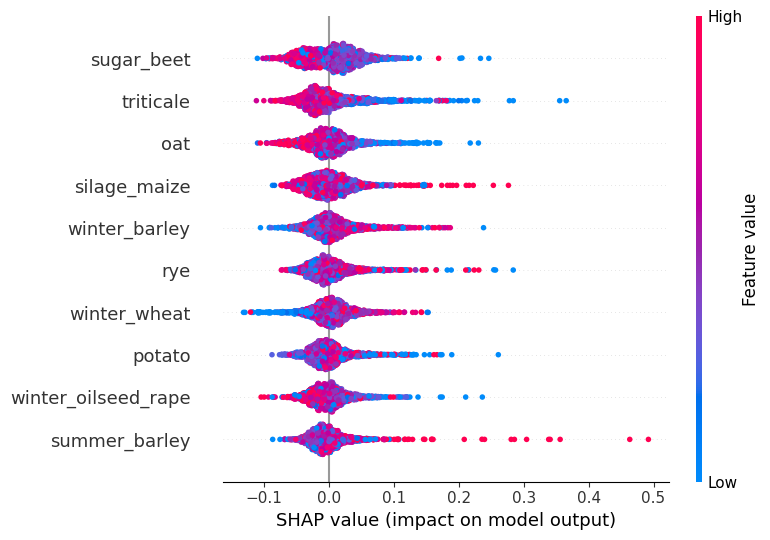

In [ ]:
# ===========================================================
# SHAP SUMMARY PLOT (IMPORTANCIA GLOBAL)
# ============================================================

shap.summary_plot(shap_values, X_sample, plot_type="dot")

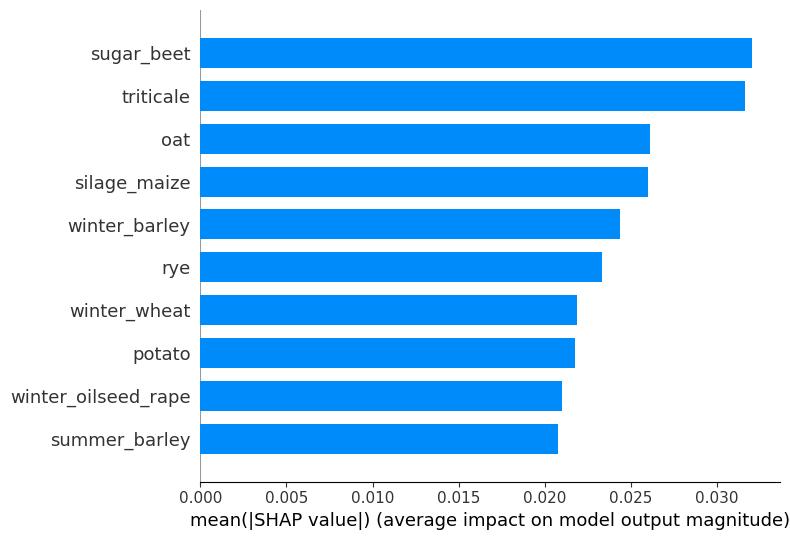

In [43]:
# ===========================================================
# FEATURE IMPORTANCE (SHAP BARS)
# ============================================================

shap.summary_plot(shap_values, X_sample, plot_type="bar")

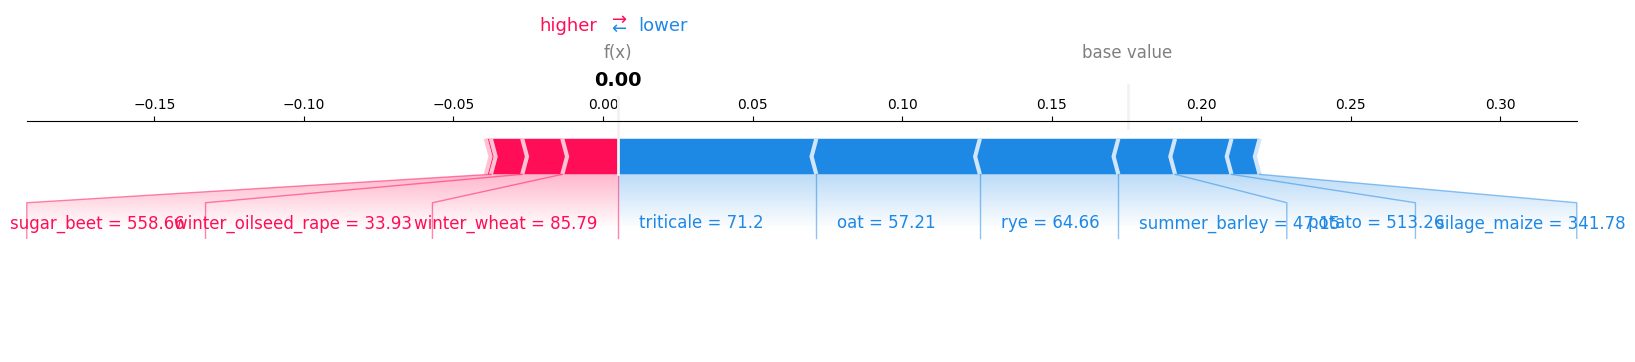

In [42]:
# ===========================================================
# EXPLICACIÓN LOCAL PARA UNA OBSERVACIÓN
# ============================================================

idx = 0  # ejemplo: primera observación del test
shap.force_plot(
    explainer.expected_value,
    shap_values[idx,:],
    X_sample.iloc[idx,:],
    matplotlib=True
)

## 2